In [1]:
import importlib
import torch
import pandas as pd
import numpy as np
import model_code.hidden_state_analysis as analysis
from sklearn.model_selection import KFold
from collections import defaultdict

import matplotlib.pyplot as plt
np.random.seed(42)
seed = 42

# import model_code.steering_extraction as steering_extraction
# from model_code.steering_extraction import  generateSteering, retrieve_steering_vector

importlib.reload(analysis)



def create_performance_dict():
    return defaultdict(lambda: defaultdict(list))

def create_multiclass_performance_dict():
    return defaultdict(lambda: defaultdict(object))

# Data Preparation

In [2]:
# Loaoding dataset 
# LLAMA original 
Llama_eng_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.pt" , weights_only = False)
Llama_eng_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/emotion_vectors.pt", weights_only = False)

Llama_eng_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
Llama_eng_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

# LLAMA Indonesian 
Llama_indo_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)
Llama_indo_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)

Llama_indo_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/steering_vectors.pt")
Llama_indo_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/steering_vectors.pt")



In [9]:
print(len(Llama_indo_emotion_vector_eng['anger']))
Llama_indo_emotion_vector_eng['anger'][0].shape

400


(32, 4096)

In [3]:

all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

# x = np.stack(Llama_indo_emotion_vector_eng['anger'], axis=0)

# x.shape
# Modify the dataset to be in dict form
mdfLLAMAD_ID_eng ={
    emo: np.stack(Llama_indo_emotion_vector_eng[emo], axis=0)
    for emo in all_emotions
}
mdfLLAMAD_ID_id = {
    emo: np.stack(Llama_indo_emotion_vector_id[emo], axis=0)
    for emo in all_emotions
}

mdfLLAMAD_ENG_eng ={
    emo: np.stack(Llama_eng_emotion_vector_eng[emo], axis=0)
    for emo in all_emotions
}
mdfLLAMAD_ENG_id = {
    emo: np.stack(Llama_eng_emotion_vector_id[emo], axis=0)
    for emo in all_emotions
}

# For statistical analysis later, create 8 fold
splitter = KFold(
    n_splits=8,
    shuffle=True,
    random_state=42,
)

statistics_LLAMA_ID_eng = {
    emo: list(splitter.split(mdfLLAMAD_ID_eng[emo]))
    for emo in all_emotions
}

statistics_LLAMA_ID_id = {
    emo: list(splitter.split(mdfLLAMAD_ID_id[emo]))
    for emo in all_emotions
}

statistics_LLAMA_ENG_eng = {
    emo: list(splitter.split(mdfLLAMAD_ENG_eng[emo]))
    for emo in all_emotions
}

statistics_LLAMA_ENG_id = {
    emo: list(splitter.split(mdfLLAMAD_ENG_id[emo]))
    for emo in all_emotions
}


# Multi-Class Probing 
We train the multiclass probe, with eight fold validation

## Llama Indonesian 

In [4]:
# Eight-fold multiclass probing across all layers
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_tests = list(range(32))
multiclass_label = 'all_emotions'

multiprobe_eng = create_performance_dict()
multiprobe_id = create_performance_dict()

english_english_multiprobe_performance = create_performance_dict()
english_indonesian_multiprobe_performance = create_performance_dict()
indonesian_indonesian_multiprobe_performance = create_performance_dict()
indonesian_english_multiprobe_performance = create_performance_dict()

Llama_eng_english_english_multiprobe_performance = create_performance_dict()
Llama_eng_english_indonesian_multiprobe_performance = create_performance_dict()
Llama_eng_indonesian_indonesian_multiprobe_performance = create_performance_dict()
Llama_eng_indonesian_english_multiprobe_performance = create_performance_dict()

for layer in layer_tests:

    # MODIFY DATASET FOR MULTICLASS PROBING
    # Llama Indonesian 
    Llama_id_eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    Llama_id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_id[emotion][:, layer, :])
        for emotion in all_emotions
    }
    # Llama English
    Llama_eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ENG_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    Llama_eng_id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ENG_id[emotion][:, layer, :])
        for emotion in all_emotions
    }

    # CREATE FOLDS FOR MULTICLASS PROBING
    # Llama Indonesian 
    Llama_id_eng_folds = analysis.create_fold_dataloaders(
        emotion_dict=Llama_id_eng_layer_dict,
        emotion=all_emotions[0],
        seed=seed,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    Llama_id_folds = analysis.create_fold_dataloaders(
        emotion_dict=Llama_id_layer_dict,
        emotion=all_emotions[0],
        seed=seed,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    # Llama English
    Llama_eng_folds = analysis.create_fold_dataloaders(
        emotion_dict=Llama_eng_layer_dict,
        emotion=all_emotions[0],
        seed=seed,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    Llama_eng_id_folds = analysis.create_fold_dataloaders(
        emotion_dict=Llama_eng_id_layer_dict,
        emotion=all_emotions[0],
        seed=seed,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )


    # TRAINING AND EVALUATE MULTICLASS PROBES FOR EACH FOLD
    for (id_eng_train, id_eng_val), (id_id_train, id_id_val), (eng_eng_train, eng_eng_val), (eng_id_train, eng_id_val) in zip(
        Llama_id_eng_folds, Llama_id_folds, Llama_eng_folds, Llama_eng_id_folds
    ):
        # Initilise probes 
        # Llama Indonesian
        Llama_id_probe_eng_model = analysis.LogisticRegressionProbe(
            input_dim=Llama_id_eng_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )
        Llama_id_probe_id_model = analysis.LogisticRegressionProbe(
            input_dim=Llama_id_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )

        # Llama English
        Llama_eng_probe_eng_model = analysis.LogisticRegressionProbe(
            input_dim=Llama_eng_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )
        Llama_eng_probe_id_model = analysis.LogisticRegressionProbe(
            input_dim=Llama_eng_id_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )

        # Train the probes for Llama Indonesian
        Llama_id_trained_eng_probe = analysis.trainMultiClassProbe(
            Llama_id_probe_eng_model, id_eng_train, id_eng_val, num_epochs=25
        )
        Llama_id_trained_id_probe = analysis.trainMultiClassProbe(
            Llama_id_probe_id_model, id_id_train, id_id_val, num_epochs=25
        )
        # Train the probes for Llama English
        Llama_eng_trained_eng_probe = analysis.trainMultiClassProbe(
            Llama_eng_probe_eng_model, eng_eng_train, eng_eng_val, num_epochs=25
        )
        Llama_eng_trained_id_probe = analysis.trainMultiClassProbe(
            Llama_eng_probe_id_model, eng_id_train, eng_id_val, num_epochs=25
        )

        # Llama Indonesian 
        multiprobe_eng[layer][multiclass_label].append(Llama_id_trained_eng_probe)
        multiprobe_id[layer][multiclass_label].append(Llama_id_trained_id_probe)

        english_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_id_trained_eng_probe, id_eng_val, multiclass=True).mean())
        )
        english_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_id_trained_eng_probe, id_id_val, multiclass=True).mean())
        )
        indonesian_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_id_trained_id_probe, id_id_val, multiclass=True).mean())
        )
        indonesian_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_id_trained_id_probe, id_eng_val, multiclass=True).mean())
        )

        # Llama English 
        Llama_eng_english_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_eng_trained_eng_probe, eng_eng_val, multiclass=True).mean())
        )
        Llama_eng_english_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_eng_trained_eng_probe, eng_id_val, multiclass=True).mean())
        )
        Llama_eng_indonesian_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_eng_trained_id_probe, eng_id_val, multiclass=True).mean())
        )
        Llama_eng_indonesian_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(Llama_eng_trained_id_probe, eng_eng_val, multiclass=True).mean())
        )


# Summarize same-language multiclass probe performance across folds
same_language_rows = []

for layer in layer_tests:
    same_language_scores = {
        "Llama_ID_EN_EN": np.asarray(
            english_english_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ID_ID_ID": np.asarray(
            indonesian_indonesian_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ENG_EN_EN": np.asarray(
            Llama_eng_english_english_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ENG_ID_ID": np.asarray(
            Llama_eng_indonesian_indonesian_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
    }

    invalid_counts = {
        direction: len(scores)
        for direction, scores in same_language_scores.items()
        if len(scores) != 8
    }
    if invalid_counts:
        raise ValueError(
            f"Layer {layer}: expected 8 fold scores, found {invalid_counts}"
        )

    row = {"layer": layer}
    for direction, scores in same_language_scores.items():
        row[f"{direction}_mean"] = scores.mean()
        row[f"{direction}_std"] = scores.std(ddof=1)
    same_language_rows.append(row)

multiclass_statistical_results_df = pd.DataFrame(same_language_rows)

# Print/display the same-language performance data
display(multiclass_statistical_results_df.round(4))

Epoch 1/25, Loss: 1.6069
Validation Accuracy: 0.3360
Epoch 2/25, Loss: 1.5974
Validation Accuracy: 0.4440
Epoch 3/25, Loss: 1.5886
Validation Accuracy: 0.4480
Epoch 4/25, Loss: 1.5810
Validation Accuracy: 0.5200
Epoch 5/25, Loss: 1.5722
Validation Accuracy: 0.5240
Epoch 6/25, Loss: 1.5638
Validation Accuracy: 0.5240
Epoch 7/25, Loss: 1.5553
Validation Accuracy: 0.5400
Epoch 8/25, Loss: 1.5482
Validation Accuracy: 0.4560
Epoch 9/25, Loss: 1.5396
Validation Accuracy: 0.5120
Epoch 10/25, Loss: 1.5326
Validation Accuracy: 0.5280
Epoch 11/25, Loss: 1.5249
Validation Accuracy: 0.5120
Epoch 12/25, Loss: 1.5173
Validation Accuracy: 0.5160
Epoch 13/25, Loss: 1.5097
Validation Accuracy: 0.5360
Epoch 14/25, Loss: 1.5037
Validation Accuracy: 0.4920
Epoch 15/25, Loss: 1.4951
Validation Accuracy: 0.5320
Epoch 16/25, Loss: 1.4881
Validation Accuracy: 0.5320
Epoch 17/25, Loss: 1.4812
Validation Accuracy: 0.5120
Epoch 18/25, Loss: 1.4740
Validation Accuracy: 0.5280
Epoch 19/25, Loss: 1.4674
Validation 

,layer,Llama_ID_EN_EN_mean,Llama_ID_EN_EN_std,Llama_ID_ID_ID_mean,Llama_ID_ID_ID_std,Llama_ENG_EN_EN_mean,Llama_ENG_EN_EN_std,Llama_ENG_ID_ID_mean,Llama_ENG_ID_ID_std
0,0,0.5840,0.0232,0.7350,0.0237,0.5535,0.0348,0.6695,0.0244
1,1,0.4820,0.0705,0.6900,0.0388,0.4870,0.0705,0.6785,0.0390
2,2,0.5740,0.0337,0.7770,0.0241,0.5780,0.0499,0.7635,0.0230
3,3,0.6580,0.0183,0.8370,0.0301,0.6375,0.0275,0.7795,0.0365
4,4,0.6875,0.0165,0.8715,0.0212,0.6760,0.0135,0.8290,0.0291
5,5,0.6880,0.0220,0.8875,0.0168,0.6805,0.0138,0.8465,0.0216
6,6,0.6965,0.0289,0.9150,0.0136,0.6850,0.0217,0.8825,0.0220
7,7,0.6970,0.0133,0.9095,0.0180,0.6790,0.0257,0.8825,0.0203
8,8,0.6900,0.0275,0.9000,0.0248,0.6635,0.0411,0.8670,0.0261
9,9,0.6780,0.0190,0.9020,0.0206,0.6585,0.0292,0.8615,0.0238


### Plots the result

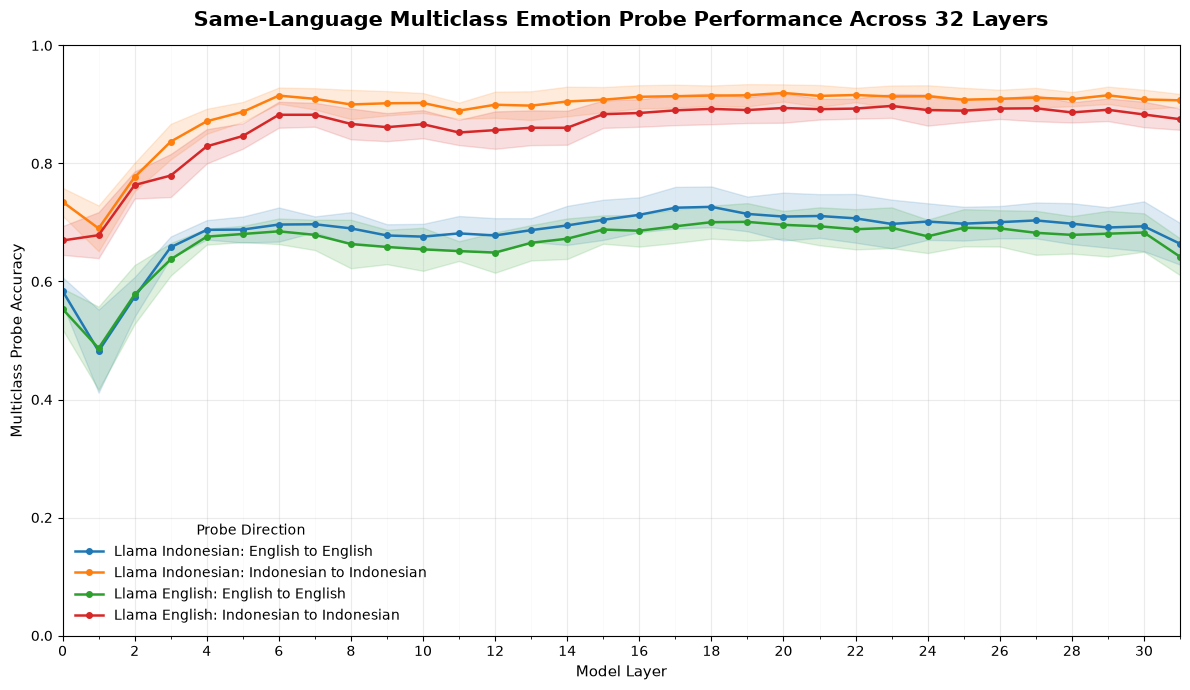

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

output_directory = Path("images/multiclass_probe_results")
output_directory.mkdir(parents=True, exist_ok=True)

same_language_directions = {
    "Llama_ID_EN_EN": "Llama Indonesian: English to English",
    "Llama_ID_ID_ID": "Llama Indonesian: Indonesian to Indonesian",
    "Llama_ENG_EN_EN": "Llama English: English to English",
    "Llama_ENG_ID_ID": "Llama English: Indonesian to Indonesian",
}

cross_languange_directions = {
    "Llama_ID_EN_ID": "Llama Indonesian: English to Indonesian",
    "Llama_ID_ID_EN": "Llama Indonesian: Indonesian to English",
    "Llama_ENG_EN_ID": "Llama English: English to Indonesian",
    "Llama_ENG_ID_EN": "Llama English: Indonesian to English",
}

all_layers = list(range(32))
chance_accuracy = 1 / len(all_emotions)  # 0.20 for five emotions

plot_df = (
    multiclass_statistical_results_df[
        multiclass_statistical_results_df["layer"].between(0, 31)
    ]
    .sort_values("layer")
    .copy()
)

fig, ax = plt.subplots(
    figsize=(12, 7),
)

for direction, direction_label in same_language_directions.items():
    layers = plot_df["layer"].to_numpy()
    means = plot_df[f"{direction}_mean"].to_numpy()
    stds = plot_df[f"{direction}_std"].to_numpy()

    line = ax.plot(
        layers,
        means,
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=direction_label,
    )[0]

    ax.fill_between(
        layers,
        means - stds,
        means + stds,
        color=line.get_color(),
        alpha=0.15,
    )


ax.set_title(
    "Same-Language Multiclass Emotion Probe Performance Across 32 Layers",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Model Layer",
    fontsize=11,
)

ax.set_ylabel(
    "Multiclass Probe Accuracy",
    fontsize=11,
)

ax.set_xlim(0, 31)
ax.set_ylim(0, 1.0)

# Show numbered labels every two layers
ax.set_xticks(range(0, 32, 2))

# Keep a minor tick at every layer
ax.set_xticks(all_layers, minor=True)

ax.grid(
    axis="both",
    which="major",
    alpha=0.25,
    linewidth=0.8,
)

ax.grid(
    axis="x",
    which="minor",
    alpha=0.08,
    linewidth=0.5,
)

ax.legend(
    title="Probe Direction",
    loc="best",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

fig.tight_layout()

output_path = (
    output_directory
    / "combined_same_language_multiclass_probe_performance.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

,layer,Llama_ID_EN_ID_mean,Llama_ID_EN_ID_std,Llama_ID_ID_EN_mean,Llama_ID_ID_EN_std,Llama_ENG_EN_ID_mean,Llama_ENG_EN_ID_std,Llama_ENG_ID_EN_mean,Llama_ENG_ID_EN_std
0,0,0.2260,0.0103,0.2070,0.0088,0.2205,0.0097,0.2035,0.0101
1,1,0.2265,0.0256,0.2145,0.0133,0.2395,0.0295,0.2220,0.0115
2,2,0.3190,0.0439,0.2415,0.0302,0.2575,0.0233,0.2150,0.0090
3,3,0.4805,0.0312,0.4040,0.0449,0.3205,0.0318,0.3265,0.0206
4,4,0.7210,0.0393,0.5570,0.0308,0.5480,0.0209,0.4670,0.0466
5,5,0.7700,0.0293,0.5690,0.0365,0.6270,0.0291,0.4985,0.0460
6,6,0.8020,0.0331,0.5855,0.0401,0.6910,0.0293,0.5615,0.0250
7,7,0.8095,0.0307,0.5775,0.0289,0.7305,0.0212,0.5625,0.0305
8,8,0.8035,0.0251,0.5780,0.0363,0.7075,0.0435,0.5455,0.0273
9,9,0.7945,0.0331,0.5610,0.0378,0.6895,0.0358,0.5430,0.0297


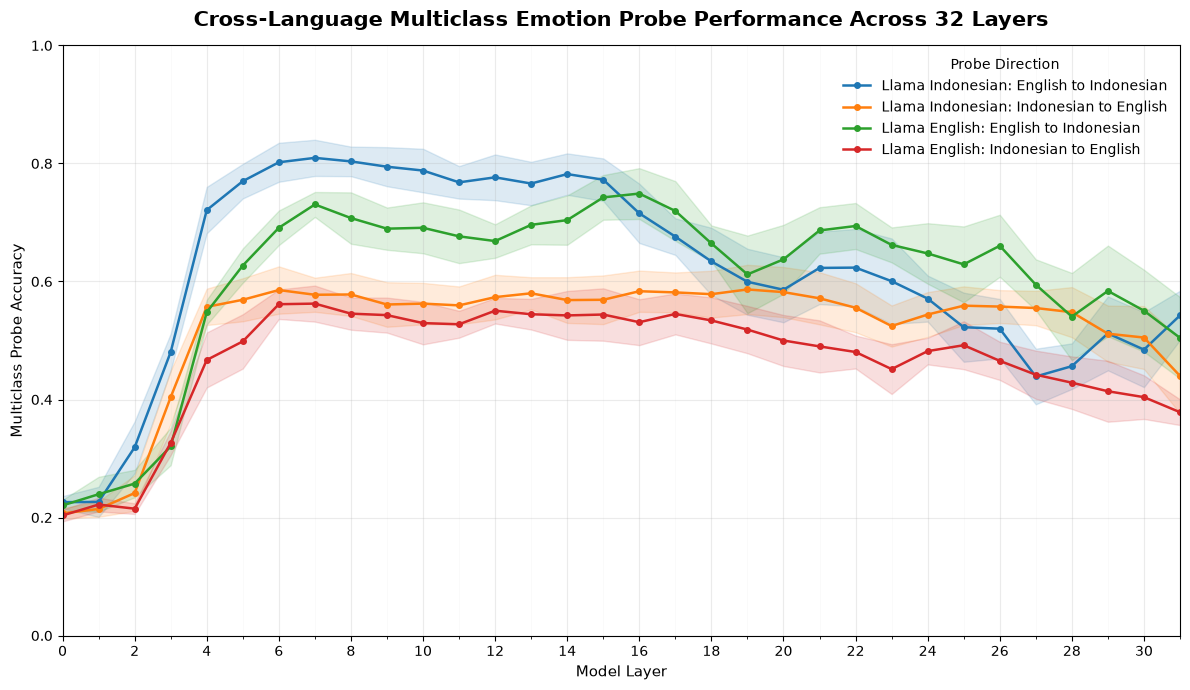

In [8]:
# Summarize and plot cross-language multiclass probe performance
cross_language_directions = {
    "Llama_ID_EN_ID": "Llama Indonesian: English to Indonesian",
    "Llama_ID_ID_EN": "Llama Indonesian: Indonesian to English",
    "Llama_ENG_EN_ID": "Llama English: English to Indonesian",
    "Llama_ENG_ID_EN": "Llama English: Indonesian to English",
}
cross_language_rows = []

for layer in layer_tests:
    cross_language_scores = {
        "Llama_ID_EN_ID": np.asarray(
            english_indonesian_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ID_ID_EN": np.asarray(
            indonesian_english_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ENG_EN_ID": np.asarray(
            Llama_eng_english_indonesian_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
        "Llama_ENG_ID_EN": np.asarray(
            Llama_eng_indonesian_english_multiprobe_performance[layer][multiclass_label], dtype=float
        ),
    }

    invalid_counts = {
        direction: len(scores)
        for direction, scores in cross_language_scores.items()
        if len(scores) != 8
    }
    if invalid_counts:
        raise ValueError(
            f"Layer {layer}: expected 8 fold scores, found {invalid_counts}"
        )

    row = {"layer": layer}
    for direction, scores in cross_language_scores.items():
        row[f"{direction}_mean"] = scores.mean()
        row[f"{direction}_std"] = scores.std(ddof=1)
    cross_language_rows.append(row)

cross_language_results_df = pd.DataFrame(cross_language_rows)
display(cross_language_results_df.round(4))

fig, ax = plt.subplots(figsize=(12, 7))

for direction, direction_label in cross_language_directions.items():
    layers = cross_language_results_df["layer"].to_numpy()
    means = cross_language_results_df[f"{direction}_mean"].to_numpy()
    stds = cross_language_results_df[f"{direction}_std"].to_numpy()

    line = ax.plot(
        layers, means, marker="o", markersize=4, linewidth=1.8, label=direction_label
    )[0]
    ax.fill_between(
        layers, means - stds, means + stds, color=line.get_color(), alpha=0.15
    )

ax.set_title(
    "Cross-Language Multiclass Emotion Probe Performance Across 32 Layers",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Model Layer", fontsize=11)
ax.set_ylabel("Multiclass Probe Accuracy", fontsize=11)
ax.set_xlim(0, 31)
ax.set_ylim(0, 1.0)
ax.set_xticks(range(0, 32, 2))
ax.set_xticks(all_layers, minor=True)
ax.grid(axis="both", which="major", alpha=0.25, linewidth=0.8)
ax.grid(axis="x", which="minor", alpha=0.08, linewidth=0.5)
ax.legend(
    title="Probe Direction",
    loc="best",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

fig.tight_layout()
output_path = output_directory / "combined_cross_language_multiclass_probe_performance.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Binary Probes 

## Training Binary Probes 

In [4]:
# Eight-fold binary probing across all layers using both Llama models
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_tests = list(range(32))

probe_eng = create_performance_dict()
probe_id = create_performance_dict()

english_english_probe_performance = create_performance_dict()
english_indonesian_probe_performance = create_performance_dict()
indonesian_indonesian_probe_performance = create_performance_dict()
indonesian_english_probe_performance = create_performance_dict()

Llama_eng_english_english_probe_performance = create_performance_dict()
Llama_eng_english_indonesian_probe_performance = create_performance_dict()
Llama_eng_indonesian_indonesian_probe_performance = create_performance_dict()
Llama_eng_indonesian_english_probe_performance = create_performance_dict()

for layer in layer_tests:
    id_eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    id_id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_id[emotion][:, layer, :])
        for emotion in all_emotions
    }
    eng_eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ENG_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    eng_id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ENG_id[emotion][:, layer, :])
        for emotion in all_emotions
    }

    for emotion in all_emotions:
        # Create folds for both models and both languages
        id_eng_folds = analysis.create_fold_dataloaders(
            emotion_dict=id_eng_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )
        id_id_folds = analysis.create_fold_dataloaders(
            emotion_dict=id_id_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )
        eng_eng_folds = analysis.create_fold_dataloaders(
            emotion_dict=eng_eng_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )
        eng_id_folds = analysis.create_fold_dataloaders(
            emotion_dict=eng_id_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )

        for (id_eng_train, id_eng_val), (id_id_train, id_id_val), (eng_eng_train, eng_eng_val), (eng_id_train, eng_id_val) in zip(
            id_eng_folds, id_id_folds, eng_eng_folds, eng_id_folds
        ):
            # Initialise the probes
            id_probe_eng_model = analysis.LogisticRegressionProbe(
                input_dim=id_eng_layer_dict[emotion].shape[-1],
                output_dim=1,
            )
            id_probe_id_model = analysis.LogisticRegressionProbe(
                input_dim=id_id_layer_dict[emotion].shape[-1],
                output_dim=1,
            )
            eng_probe_eng_model = analysis.LogisticRegressionProbe(
                input_dim=eng_eng_layer_dict[emotion].shape[-1],
                output_dim=1,
            )
            eng_probe_id_model = analysis.LogisticRegressionProbe(
                input_dim=eng_id_layer_dict[emotion].shape[-1],
                output_dim=1,
            )

            # Train the probes
            id_trained_eng_probe = analysis.trainProbe(
                id_probe_eng_model, id_eng_train, id_eng_val
            )
            id_trained_id_probe = analysis.trainProbe(
                id_probe_id_model, id_id_train, id_id_val
            )
            eng_trained_eng_probe = analysis.trainProbe(
                eng_probe_eng_model, eng_eng_train, eng_eng_val
            )
            eng_trained_id_probe = analysis.trainProbe(
                eng_probe_id_model, eng_id_train, eng_id_val
            )

            # Record Indonesian Llama performance
            english_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(id_trained_eng_probe, id_eng_val).mean())
            )
            english_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(id_trained_eng_probe, id_id_val).mean())
            )
            indonesian_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(id_trained_id_probe, id_id_val).mean())
            )
            indonesian_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(id_trained_id_probe, id_eng_val).mean())
            )

            # Record English Llama performance
            Llama_eng_english_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(eng_trained_eng_probe, eng_eng_val).mean())
            )
            Llama_eng_english_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(eng_trained_eng_probe, eng_id_val).mean())
            )
            Llama_eng_indonesian_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(eng_trained_id_probe, eng_id_val).mean())
            )
            Llama_eng_indonesian_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(eng_trained_id_probe, eng_eng_val).mean())
            )

statistical_rows = []
performance_by_direction = {
    'Llama_ID_EN->EN': english_english_probe_performance,
    'Llama_ID_EN->ID': english_indonesian_probe_performance,
    'Llama_ID_ID->ID': indonesian_indonesian_probe_performance,
    'Llama_ID_ID->EN': indonesian_english_probe_performance,
    'Llama_ENG_EN->EN': Llama_eng_english_english_probe_performance,
    'Llama_ENG_EN->ID': Llama_eng_english_indonesian_probe_performance,
    'Llama_ENG_ID->ID': Llama_eng_indonesian_indonesian_probe_performance,
    'Llama_ENG_ID->EN': Llama_eng_indonesian_english_probe_performance,
}

for layer in layer_tests:
    for emotion in all_emotions:
        row = {'layer': layer, 'emotion': emotion}
        for direction, performance in performance_by_direction.items():
            fold_accuracies = performance[layer][emotion]
            if len(fold_accuracies) != 8:
                raise ValueError(
                    f'{direction}, layer {layer}, {emotion}: expected 8 fold scores, '
                    f'found {len(fold_accuracies)}'
                )
            row[f'{direction}_mean'] = float(np.mean(fold_accuracies))
            row[f'{direction}_std'] = float(np.std(fold_accuracies, ddof=1))
        statistical_rows.append(row)

statistical_probe_results_df = pd.DataFrame(statistical_rows)
display(statistical_probe_results_df.round(4))
print('Each model/layer/emotion contains 8 fold accuracies per direction.')

Epoch 1/10, Loss: 0.6933
Validation Accuracy: 0.5000
Epoch 2/10, Loss: 0.6916
Validation Accuracy: 0.7400
Epoch 3/10, Loss: 0.6904
Validation Accuracy: 0.6100
Epoch 4/10, Loss: 0.6890
Validation Accuracy: 0.7200
Epoch 5/10, Loss: 0.6877
Validation Accuracy: 0.7100
Epoch 6/10, Loss: 0.6864
Validation Accuracy: 0.7300
Epoch 7/10, Loss: 0.6850
Validation Accuracy: 0.7000
Epoch 8/10, Loss: 0.6838
Validation Accuracy: 0.7300
Epoch 9/10, Loss: 0.6826
Validation Accuracy: 0.7100
Epoch 10/10, Loss: 0.6814
Validation Accuracy: 0.7100
Epoch 1/10, Loss: 0.6925
Validation Accuracy: 0.5000
Epoch 2/10, Loss: 0.6905
Validation Accuracy: 0.5700
Epoch 3/10, Loss: 0.6887
Validation Accuracy: 0.5700
Epoch 4/10, Loss: 0.6872
Validation Accuracy: 0.6400
Epoch 5/10, Loss: 0.6853
Validation Accuracy: 0.6600
Epoch 6/10, Loss: 0.6836
Validation Accuracy: 0.6800
Epoch 7/10, Loss: 0.6817
Validation Accuracy: 0.6200
Epoch 8/10, Loss: 0.6802
Validation Accuracy: 0.6800
Epoch 9/10, Loss: 0.6784
Validation Accuracy:

,layer,emotion,Llama_ID_EN->EN_mean,Llama_ID_EN->EN_std,Llama_ID_EN->ID_mean,Llama_ID_EN->ID_std,Llama_ID_ID->ID_mean,Llama_ID_ID->ID_std,Llama_ID_ID->EN_mean,Llama_ID_ID->EN_std,Llama_ENG_EN->EN_mean,Llama_ENG_EN->EN_std,Llama_ENG_EN->ID_mean,Llama_ENG_EN->ID_std,Llama_ENG_ID->ID_mean,Llama_ENG_ID->ID_std,Llama_ENG_ID->EN_mean,Llama_ENG_ID->EN_std
0,0,anger,0.7275,0.0433,0.5125,0.0128,0.6938,0.0784,0.4950,0.0267,0.6875,0.0838,0.5025,0.0139,0.6562,0.0639,0.5012,0.0035
1,0,happiness,0.6700,0.0674,0.5825,0.0526,0.6788,0.0327,0.5038,0.0119,0.6712,0.0461,0.6000,0.0767,0.6388,0.0364,0.5000,0.0000
2,0,sadness,0.6275,0.0609,0.5212,0.0360,0.8612,0.0439,0.5012,0.0064,0.6300,0.0628,0.5062,0.0256,0.8500,0.0598,0.4988,0.0035
3,0,love,0.7475,0.1017,0.5063,0.0160,0.7538,0.0434,0.5000,0.0000,0.7812,0.0541,0.4838,0.0311,0.6900,0.0351,0.5000,0.0000
4,0,fear,0.6825,0.0501,0.4350,0.0487,0.6750,0.0472,0.4988,0.0125,0.6350,0.0298,0.4662,0.0362,0.6225,0.0385,0.5000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,31,anger,0.8038,0.0334,0.7900,0.0561,0.9025,0.0362,0.7150,0.0713,0.7925,0.0430,0.7263,0.0555,0.8625,0.0311,0.7175,0.0620
156,31,happiness,0.7425,0.0512,0.7537,0.0580,0.9250,0.0233,0.6038,0.0605,0.7550,0.0518,0.6875,0.0850,0.8962,0.0283,0.6088,0.0482
157,31,sadness,0.7975,0.0311,0.7325,0.0671,0.9112,0.0210,0.6550,0.0378,0.7675,0.0296,0.6187,0.0801,0.8800,0.0382,0.6113,0.0620
158,31,love,0.8388,0.0356,0.8650,0.0302,0.9425,0.0149,0.6688,0.0327,0.8325,0.0337,0.8138,0.0417,0.9275,0.0198,0.6275,0.0333


Each model/layer/emotion contains 8 fold accuracies per direction.


## Reporting Binary Probes 

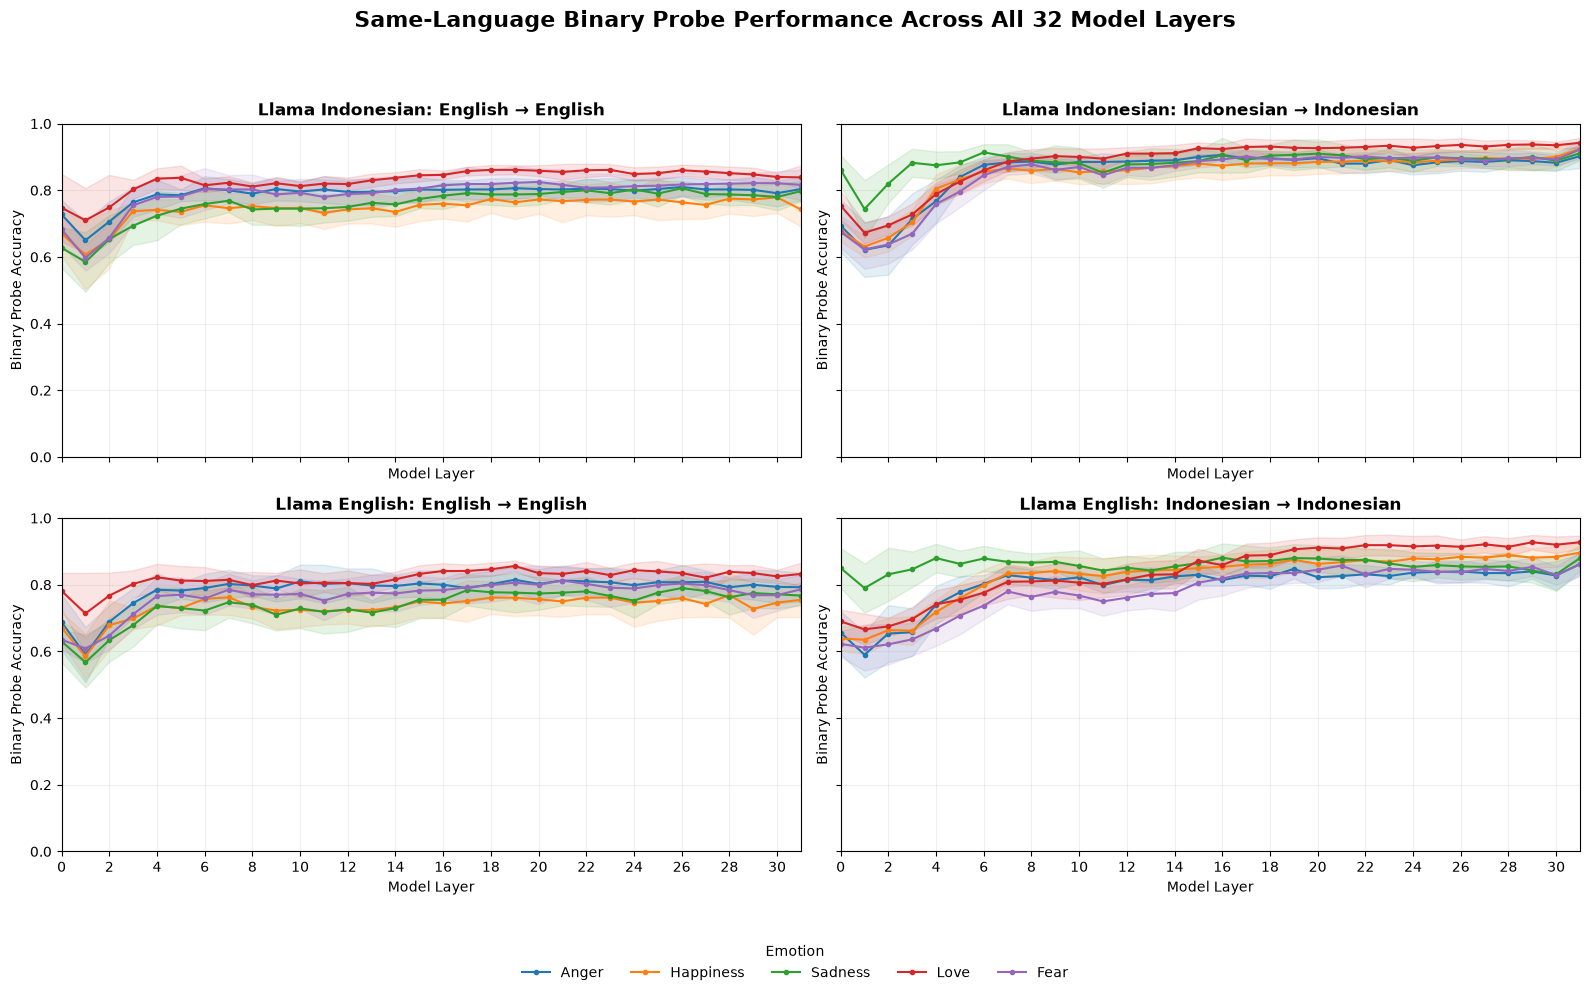

Saved figure to images/binary_probe_results/combined_same_language_binary_probe.png


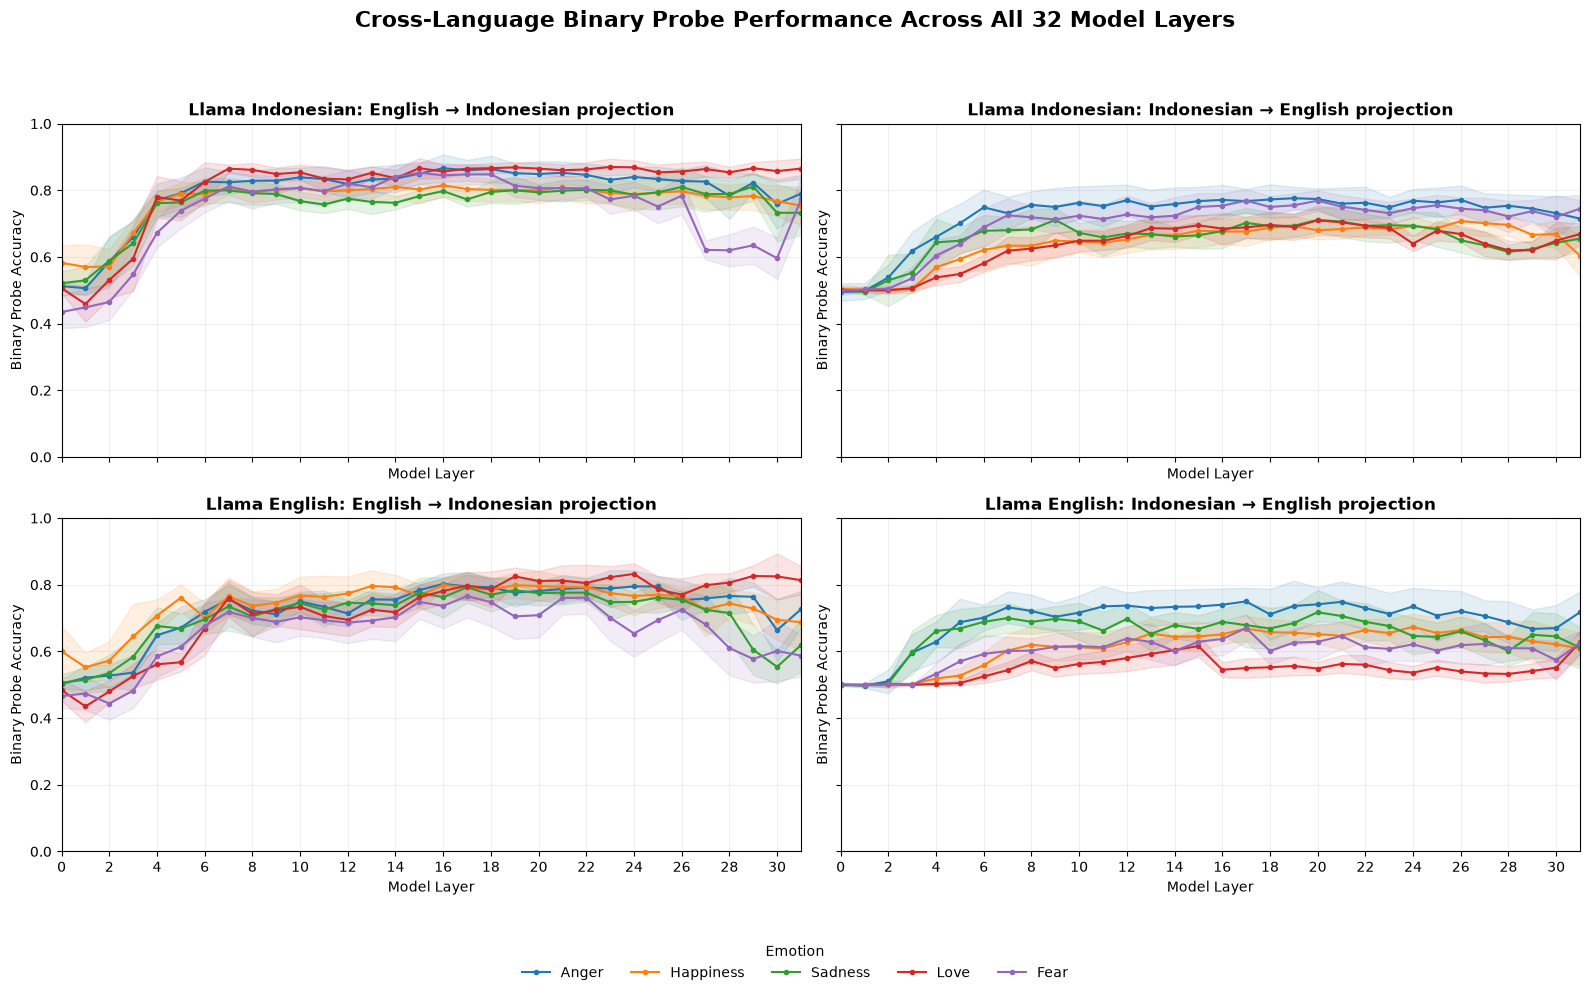

Saved figure to images/binary_probe_results/combined_cross_language_binary_probe.png


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt

# Combine both models into one same-language figure and one cross-language figure.
output_directory = Path("images/binary_probe_results")
output_directory.mkdir(parents=True, exist_ok=True)

plot_groups = {
    "same_language": {
        "EN->EN": "English → English",
        "ID->ID": "Indonesian → Indonesian",
    },
    "cross_language": {
        "EN->ID": "English → Indonesian projection",
        "ID->EN": "Indonesian → English projection",
    },
}
model_labels = {
    "Llama_ID": "Llama Indonesian",
    "Llama_ENG": "Llama English",
}

for group_name, directions in plot_groups.items():
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        sharex=True,
        sharey=True,
    )

    for model_row, (model, model_name) in enumerate(model_labels.items()):
        for direction_column, (direction, direction_name) in enumerate(directions.items()):
            ax = axes[model_row, direction_column]

            for emotion in all_emotions:
                emotion_df = statistical_probe_results_df[
                    statistical_probe_results_df["emotion"] == emotion
                ].sort_values("layer")
                layers = emotion_df["layer"].to_numpy()
                means = emotion_df[f"{model}_{direction}_mean"].to_numpy()
                stds = emotion_df[f"{model}_{direction}_std"].to_numpy()

                line = ax.plot(
                    layers,
                    means,
                    marker="o",
                    markersize=3,
                    linewidth=1.5,
                    label=emotion.title(),
                )[0]
                ax.fill_between(
                    layers,
                    np.clip(means - stds, 0, 1),
                    np.clip(means + stds, 0, 1),
                    color=line.get_color(),
                    alpha=0.12,
                )

            ax.set_title(f"{model_name}: {direction_name}", fontweight="bold")
            ax.set_xlim(0, 31)
            ax.set_ylim(0, 1.0)
            ax.set_xticks(range(0, 32, 2))
            ax.grid(alpha=0.2)
            ax.set_xlabel("Model Layer")
            ax.set_ylabel("Binary Probe Accuracy")

    group_title = "Same-Language" if group_name == "same_language" else "Cross-Language"
    fig.suptitle(
        f"{group_title} Binary Probe Performance Across All 32 Model Layers",
        fontsize=16,
        fontweight="bold",
    )
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Emotion",
        loc="lower center",
        ncol=len(all_emotions),
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.08, 1, 0.94))

    output_path = output_directory / f"combined_{group_name}_binary_probe.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved figure to {output_path}")

In [11]:
# Display fold-level binary probe results in separate early, middle, and late tables
binary_mean_columns = [
    column
    for column in statistical_probe_results_df.columns
    if column.endswith("_mean")
]

selected_layers = {
    5: "Early",
    16: "Middle",
    27: "Late",
}

selected_results = statistical_probe_results_df[
    statistical_probe_results_df["layer"].isin(selected_layers)
] .copy()

expected_rows = len(all_emotions) * len(selected_layers)
if len(selected_results) != expected_rows:
    raise ValueError(
        f"Expected {expected_rows} emotion-layer rows; found {len(selected_results)}"
    )

selected_results["Emotion"] = pd.Categorical(
    selected_results["emotion"],
    categories=all_emotions,
    ordered=True,
)
selected_results["Stage"] = pd.Categorical(
    selected_results["layer"].map(selected_layers),
    categories=list(selected_layers.values()),
    ordered=True,
)
selected_results = selected_results.sort_values(["Stage", "Emotion"])

binary_probe_emotion_table = selected_results[["Emotion", "Stage", "layer"]].rename(
    columns={"layer": "Layer"}
)

for mean_column in binary_mean_columns:
    direction = mean_column.removesuffix("_mean")
    std_column = f"{direction}_std"
    if std_column not in selected_results.columns:
        raise ValueError(f"Missing fold standard deviation column: {std_column}")

    binary_probe_emotion_table[direction] = [
        f"{mean:.4f} ± {std:.4f}"
        for mean, std in zip(
            selected_results[mean_column],
            selected_results[std_column],
        )
    ]

binary_probe_emotion_table = binary_probe_emotion_table.reset_index(drop=True)
binary_probe_tables_by_stage = {
    stage: (
        binary_probe_emotion_table[binary_probe_emotion_table["Stage"] == stage]
        .drop(columns="Stage")
        .reset_index(drop=True)
    )
    for stage in selected_layers.values()
}

for stage, stage_table in binary_probe_tables_by_stage.items():
    print(f"{stage} layer results")
    display(stage_table)

# Retain the across-emotion summary used by the following plot.
binary_probe_emotion_summary_df = (
    statistical_probe_results_df
    .melt(
        id_vars=["layer", "emotion"],
        value_vars=binary_mean_columns,
        var_name="direction",
        value_name="emotion_accuracy",
    )
    .assign(direction=lambda frame: frame["direction"].str.removesuffix("_mean"))
    .groupby(["layer", "direction"], as_index=False)["emotion_accuracy"]
    .agg(mean_accuracy="mean", std_across_emotions="std")
)

Early layer results


,Emotion,Layer,Llama_ID_EN->EN,Llama_ID_EN->ID,Llama_ID_ID->ID,Llama_ID_ID->EN,Llama_ENG_EN->EN,Llama_ENG_EN->ID,Llama_ENG_ID->ID,Llama_ENG_ID->EN
0,anger,5,0.7850 ± 0.0177,0.7913 ± 0.0470,0.8400 ± 0.0346,0.7013 ± 0.0582,0.7825 ± 0.0238,0.6713 ± 0.0633,0.7775 ± 0.0486,0.6875 ± 0.0703
1,happiness,5,0.7350 ± 0.0393,0.7900 ± 0.0338,0.8325 ± 0.0453,0.5938 ± 0.0410,0.7300 ± 0.0214,0.7612 ± 0.0394,0.7600 ± 0.0454,0.5275 ± 0.0212
2,sadness,5,0.7450 ± 0.0472,0.7637 ± 0.0437,0.8838 ± 0.0334,0.6487 ± 0.0394,0.7300 ± 0.0609,0.6687 ± 0.0452,0.8625 ± 0.0399,0.6687 ± 0.0589
3,love,5,0.8375 ± 0.0362,0.7688 ± 0.0589,0.8262 ± 0.0354,0.5488 ± 0.0236,0.8125 ± 0.0437,0.5675 ± 0.0271,0.7550 ± 0.0444,0.5050 ± 0.0076
4,fear,5,0.7812 ± 0.0633,0.7388 ± 0.0525,0.7963 ± 0.0466,0.6388 ± 0.0253,0.7700 ± 0.0518,0.6138 ± 0.0560,0.7075 ± 0.0565,0.5700 ± 0.0550


Middle layer results


,Emotion,Layer,Llama_ID_EN->EN,Llama_ID_EN->ID,Llama_ID_ID->ID,Llama_ID_ID->EN,Llama_ENG_EN->EN,Llama_ENG_EN->ID,Llama_ENG_ID->ID,Llama_ENG_ID->EN
0,anger,16,0.8013 ± 0.0295,0.8662 ± 0.0410,0.9062 ± 0.0169,0.7712 ± 0.0452,0.8000 ± 0.0431,0.8025 ± 0.0320,0.8137 ± 0.0169,0.7400 ± 0.0487
1,happiness,16,0.7600 ± 0.0447,0.8150 ± 0.0338,0.8738 ± 0.0424,0.6763 ± 0.0366,0.7438 ± 0.0447,0.7988 ± 0.0203,0.8538 ± 0.0358,0.6512 ± 0.0285
2,sadness,16,0.7837 ± 0.0396,0.7975 ± 0.0175,0.9050 ± 0.0521,0.6775 ± 0.0512,0.7550 ± 0.0537,0.7625 ± 0.0609,0.8812 ± 0.0426,0.6887 ± 0.0398
3,love,16,0.8463 ± 0.0130,0.8562 ± 0.0200,0.9237 ± 0.0160,0.6850 ± 0.0478,0.8413 ± 0.0236,0.7812 ± 0.0391,0.8588 ± 0.0314,0.5450 ± 0.0227
4,fear,16,0.8150 ± 0.0355,0.8450 ± 0.0355,0.8925 ± 0.0175,0.7537 ± 0.0378,0.7837 ± 0.0366,0.7363 ± 0.0670,0.8188 ± 0.0508,0.6375 ± 0.0498


Late layer results


,Emotion,Layer,Llama_ID_EN->EN,Llama_ID_EN->ID,Llama_ID_ID->ID,Llama_ID_ID->EN,Llama_ENG_EN->EN,Llama_ENG_EN->ID,Llama_ENG_ID->ID,Llama_ENG_ID->EN
0,anger,27,0.8025 ± 0.0306,0.8262 ± 0.0496,0.8850 ± 0.0298,0.7475 ± 0.0433,0.8088 ± 0.0348,0.7588 ± 0.0344,0.8350 ± 0.0288,0.7063 ± 0.0469
1,happiness,27,0.7563 ± 0.0417,0.7837 ± 0.0403,0.8962 ± 0.0292,0.7012 ± 0.0391,0.7425 ± 0.0385,0.7262 ± 0.0811,0.8812 ± 0.0290,0.6425 ± 0.0443
2,sadness,27,0.7888 ± 0.0290,0.7888 ± 0.0528,0.8938 ± 0.0267,0.6350 ± 0.0404,0.7812 ± 0.0304,0.7250 ± 0.0648,0.8538 ± 0.0346,0.6338 ± 0.0501
3,love,27,0.8562 ± 0.0185,0.8638 ± 0.0220,0.9312 ± 0.0181,0.6400 ± 0.0374,0.8213 ± 0.0429,0.7987 ± 0.0340,0.9212 ± 0.0247,0.5338 ± 0.0277
4,fear,27,0.8188 ± 0.0394,0.6213 ± 0.0285,0.8887 ± 0.0164,0.7400 ± 0.0374,0.7988 ± 0.0398,0.6813 ± 0.0853,0.8475 ± 0.0311,0.6225 ± 0.0627


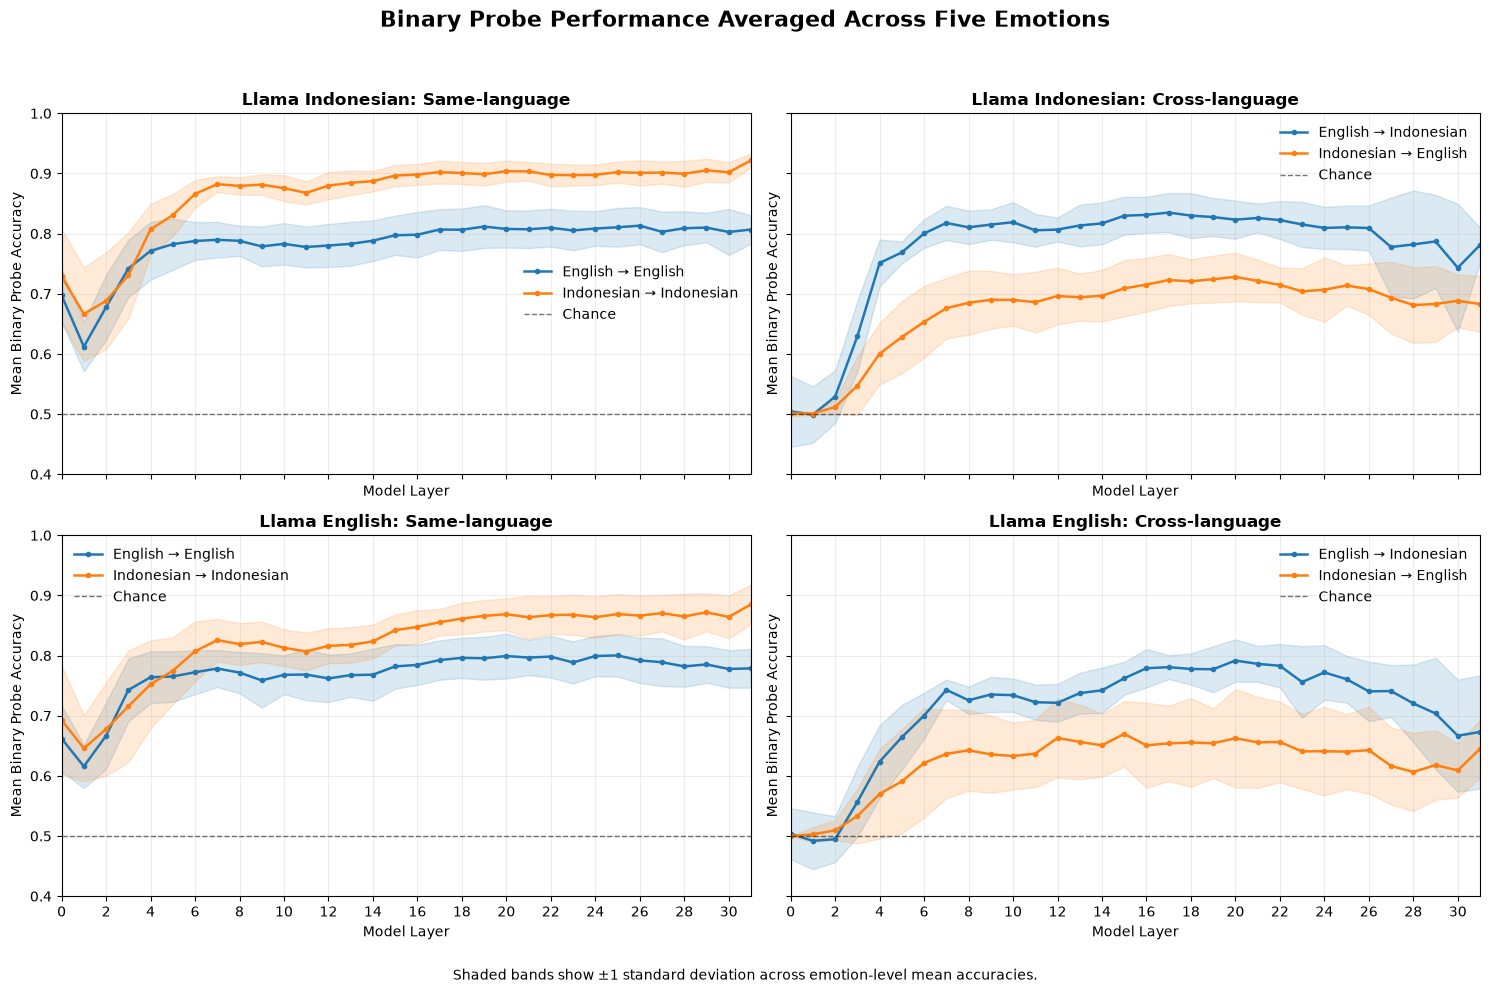

Saved figure to images/binary_probe_results/binary_probe_mean_across_emotions.png


In [20]:
# Plot mean binary-probe accuracy across emotions with across-emotion SD bands
from pathlib import Path
import matplotlib.pyplot as plt

binary_direction_groups = {
    ("Llama_ID", "Same-language"): {
        "Llama_ID_EN->EN": "English → English",
        "Llama_ID_ID->ID": "Indonesian → Indonesian",
    },
    ("Llama_ID", "Cross-language"): {
        "Llama_ID_EN->ID": "English → Indonesian",
        "Llama_ID_ID->EN": "Indonesian → English",
    },
    ("Llama_ENG", "Same-language"): {
        "Llama_ENG_EN->EN": "English → English",
        "Llama_ENG_ID->ID": "Indonesian → Indonesian",
    },
    ("Llama_ENG", "Cross-language"): {
        "Llama_ENG_EN->ID": "English → Indonesian",
        "Llama_ENG_ID->EN": "Indonesian → English",
    },
}

model_labels = {
    "Llama_ID": "Llama Indonesian",
    "Llama_ENG": "Llama English",
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)

for ax, ((model, comparison_type), directions) in zip(
    axes.flat,
    binary_direction_groups.items(),
):
    for direction, direction_label in directions.items():
        direction_df = (
            binary_probe_emotion_summary_df[
                binary_probe_emotion_summary_df["direction"] == direction
            ]
            .sort_values("layer")
        )
        layers = direction_df["layer"].to_numpy()
        means = direction_df["mean_accuracy"].to_numpy()
        stds = direction_df["std_across_emotions"].to_numpy()

        line = ax.plot(
            layers,
            means,
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=direction_label,
        )[0]
        ax.fill_between(
            layers,
            np.clip(means - stds, 0, 1),
            np.clip(means + stds, 0, 1),
            color=line.get_color(),
            alpha=0.16,
        )

    ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.55, label="Chance")
    ax.set_title(f"{model_labels[model]}: {comparison_type}", fontweight="bold")
    ax.set_xlim(0, 31)
    ax.set_ylim(0.4, 1.0)
    ax.set_xticks(range(0, 32, 2))
    ax.set_xlabel("Model Layer")
    ax.set_ylabel("Mean Binary Probe Accuracy")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, loc="best")

fig.suptitle(
    "Binary Probe Performance Averaged Across Five Emotions",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.5,
    0.01,
    "Shaded bands show ±1 standard deviation across emotion-level mean accuracies.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0.035, 1, 0.95))

output_directory = Path("images/binary_probe_results")
output_directory.mkdir(parents=True, exist_ok=True)
output_path = output_directory / "binary_probe_mean_across_emotions.png"
fig.savefig(output_path, dpi=200)
plt.show()
plt.close(fig)

print(f"Saved figure to {output_path}")

# Steering Vector Analysis 

## Cosine Matrix 

,anger,happiness,sadness,love,fear
anger,1.000000,-0.576407,0.240190,-0.585441,0.246262
happiness,-0.576407,1.000000,-0.658050,0.802629,-0.785488
sadness,0.240190,-0.658050,1.000000,-0.716025,0.617899
love,-0.585441,0.802629,-0.716025,1.000000,-0.835307
fear,0.246262,-0.785488,0.617899,-0.835307,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.681433,-0.607531,-0.858010,0.830862
happiness,0.681433,1.000000,-0.678881,-0.923080,0.821376
sadness,-0.607531,-0.678881,1.000000,0.624432,-0.596288
love,-0.858010,-0.923080,0.624432,1.000000,-0.946293
fear,0.830862,0.821376,-0.596288,-0.946293,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,-0.540299,0.150357,-0.606983,0.180175
happiness,-0.540299,1.000000,-0.468606,0.689461,-0.698363
sadness,0.150357,-0.468606,1.000000,-0.552729,0.385775
love,-0.606983,0.689461,-0.552729,1.000000,-0.726888
fear,0.180175,-0.698363,0.385775,-0.726888,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.539459,-0.472251,-0.802478,0.779238
happiness,0.539459,1.000000,-0.557660,-0.876245,0.732379
sadness,-0.472251,-0.557660,1.000000,0.478299,-0.468030
love,-0.802478,-0.876245,0.478299,1.000000,-0.925610
fear,0.779238,0.732379,-0.468030,-0.925610,1.000000


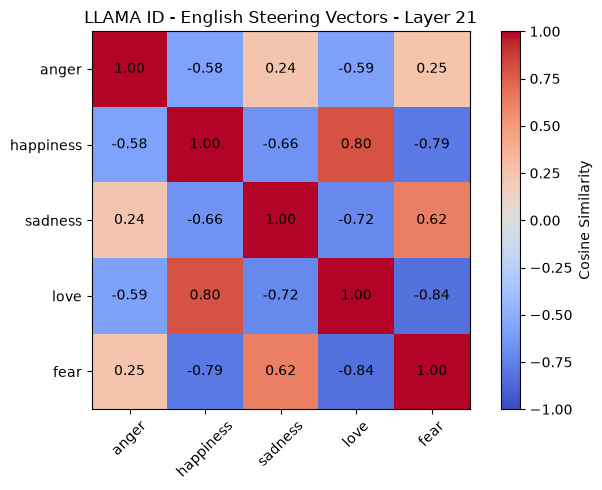

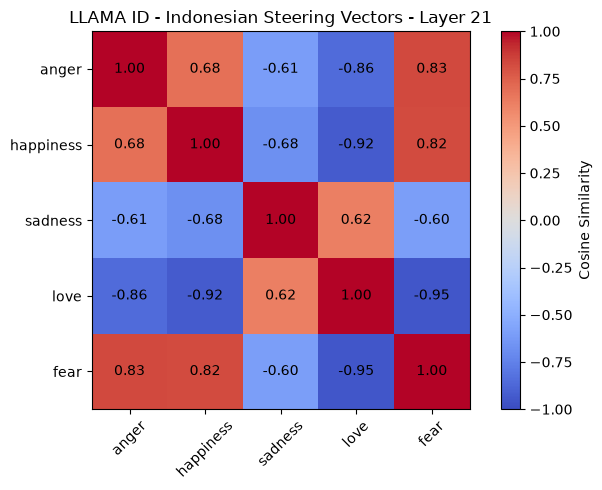

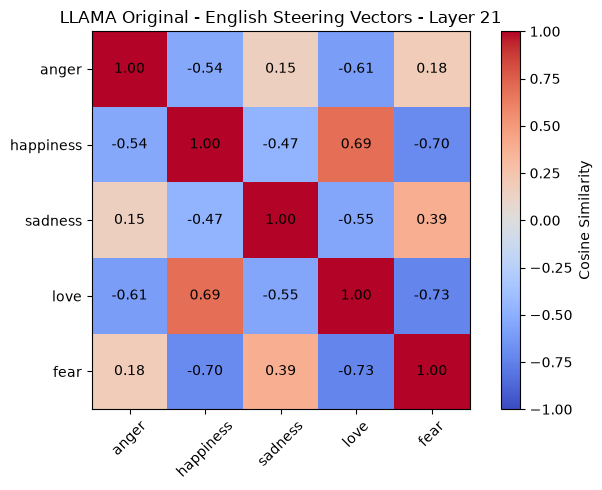

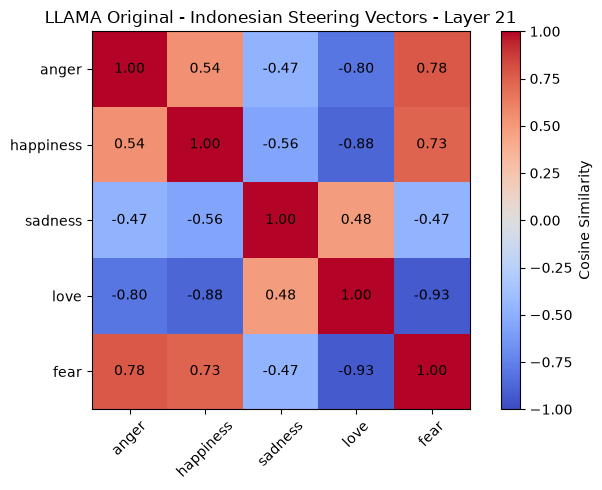

In [23]:


emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21

LLAMAID_eng_cosine_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_eng, emotions, layer_idx)
LLAMAID_id_cosine_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_id, emotions, layer_idx)

LLAMAENG_eng_cosine_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_eng, emotions, layer_idx)
LLAMAENG_id_cosine_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_id, emotions, layer_idx)


display(LLAMAID_eng_cosine_matrix)
display(LLAMAID_id_cosine_matrix)
display(LLAMAENG_eng_cosine_matrix)
display(LLAMAENG_id_cosine_matrix)


# LLAMA ID (Indonesian) - Layer 21
plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(LLAMAID_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA ID - English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAID_eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(LLAMAID_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA ID - Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAID_id_cosine_matrix.values)
plt.tight_layout()
plt.show()

# LLAMA Original (English) - Layer 21
plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(LLAMAENG_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA Original - English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAENG_eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(LLAMAENG_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA Original - Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAENG_id_cosine_matrix.values)
plt.tight_layout()
plt.show()


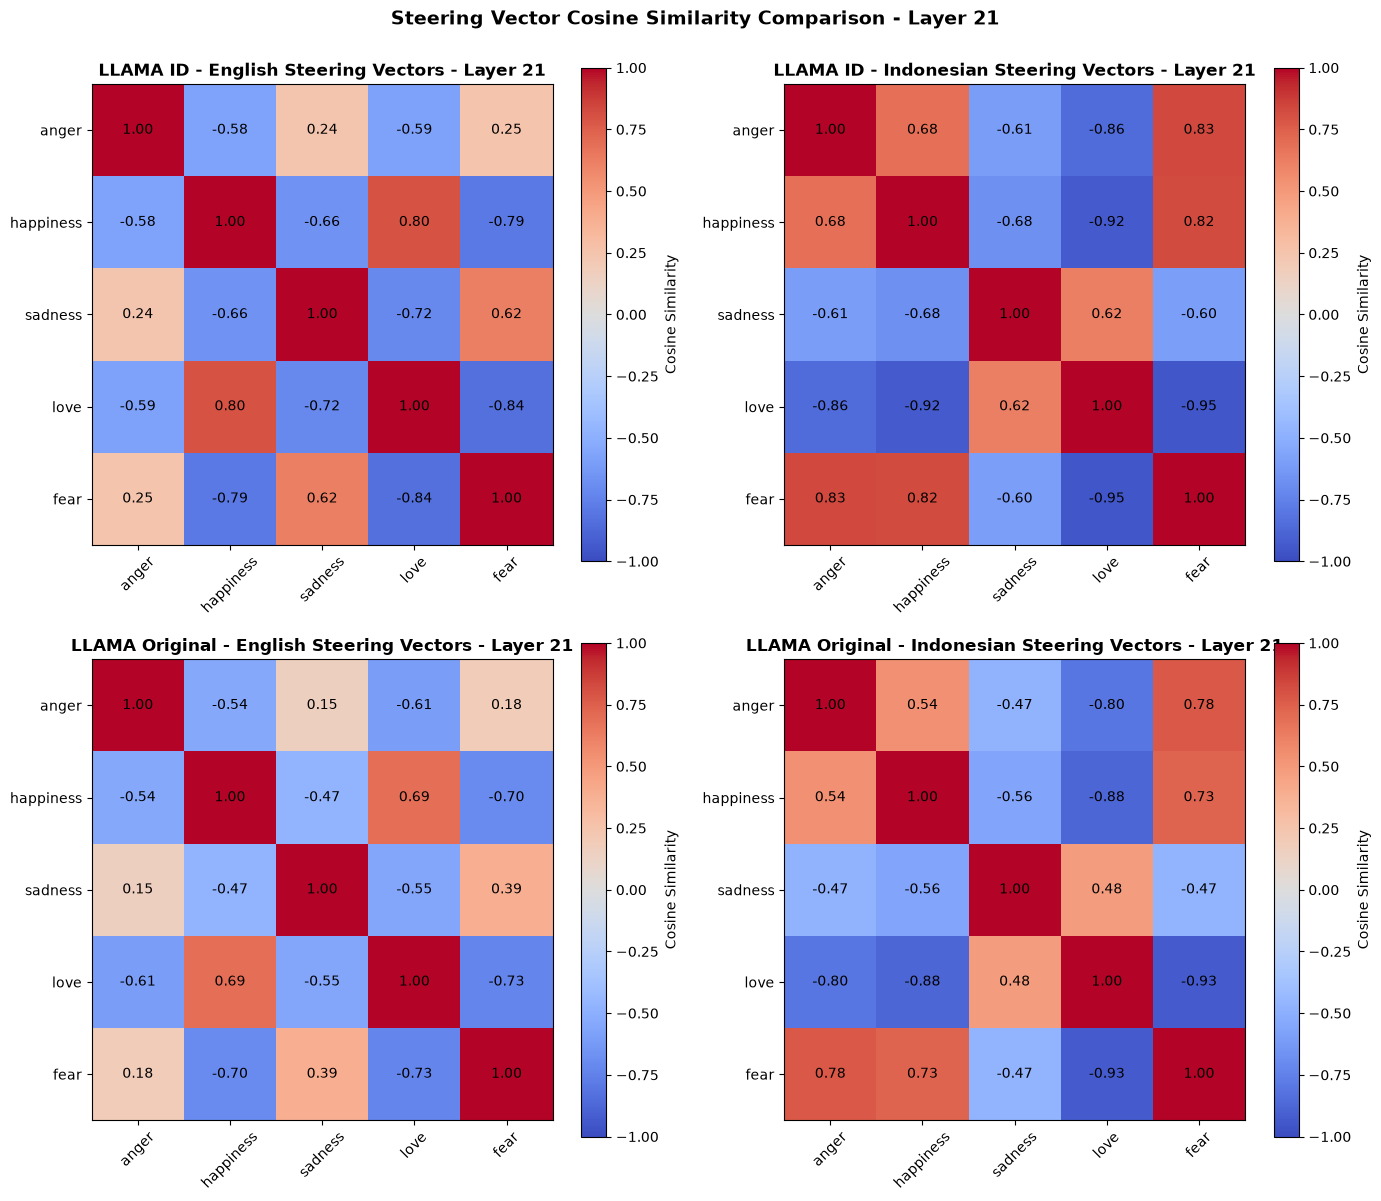

In [24]:

# All four matrices in one figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# LLAMA ID - English
im1 = axes[0, 0].imshow(LLAMAID_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[0, 0].set_xticks(range(len(emotions)))
axes[0, 0].set_yticks(range(len(emotions)))
axes[0, 0].set_xticklabels(emotions, rotation=45)
axes[0, 0].set_yticklabels(emotions)
axes[0, 0].set_title('LLAMA ID - English Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[0, 0], LLAMAID_eng_cosine_matrix.values)
plt.colorbar(im1, ax=axes[0, 0], label='Cosine Similarity')

# LLAMA ID - Indonesian
im2 = axes[0, 1].imshow(LLAMAID_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[0, 1].set_xticks(range(len(emotions)))
axes[0, 1].set_yticks(range(len(emotions)))
axes[0, 1].set_xticklabels(emotions, rotation=45)
axes[0, 1].set_yticklabels(emotions)
axes[0, 1].set_title('LLAMA ID - Indonesian Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[0, 1], LLAMAID_id_cosine_matrix.values)
plt.colorbar(im2, ax=axes[0, 1], label='Cosine Similarity')

# LLAMA Original - English
im3 = axes[1, 0].imshow(LLAMAENG_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 0].set_xticks(range(len(emotions)))
axes[1, 0].set_yticks(range(len(emotions)))
axes[1, 0].set_xticklabels(emotions, rotation=45)
axes[1, 0].set_yticklabels(emotions)
axes[1, 0].set_title('LLAMA Original - English Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[1, 0], LLAMAENG_eng_cosine_matrix.values)
plt.colorbar(im3, ax=axes[1, 0], label='Cosine Similarity')

# LLAMA Original - Indonesian
im4 = axes[1, 1].imshow(LLAMAENG_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 1].set_xticks(range(len(emotions)))
axes[1, 1].set_yticks(range(len(emotions)))
axes[1, 1].set_xticklabels(emotions, rotation=45)
axes[1, 1].set_yticklabels(emotions)
axes[1, 1].set_title('LLAMA Original - Indonesian Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[1, 1], LLAMAENG_id_cosine_matrix.values)
plt.colorbar(im4, ax=axes[1, 1], label='Cosine Similarity')

plt.suptitle('Steering Vector Cosine Similarity Comparison - Layer 21', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


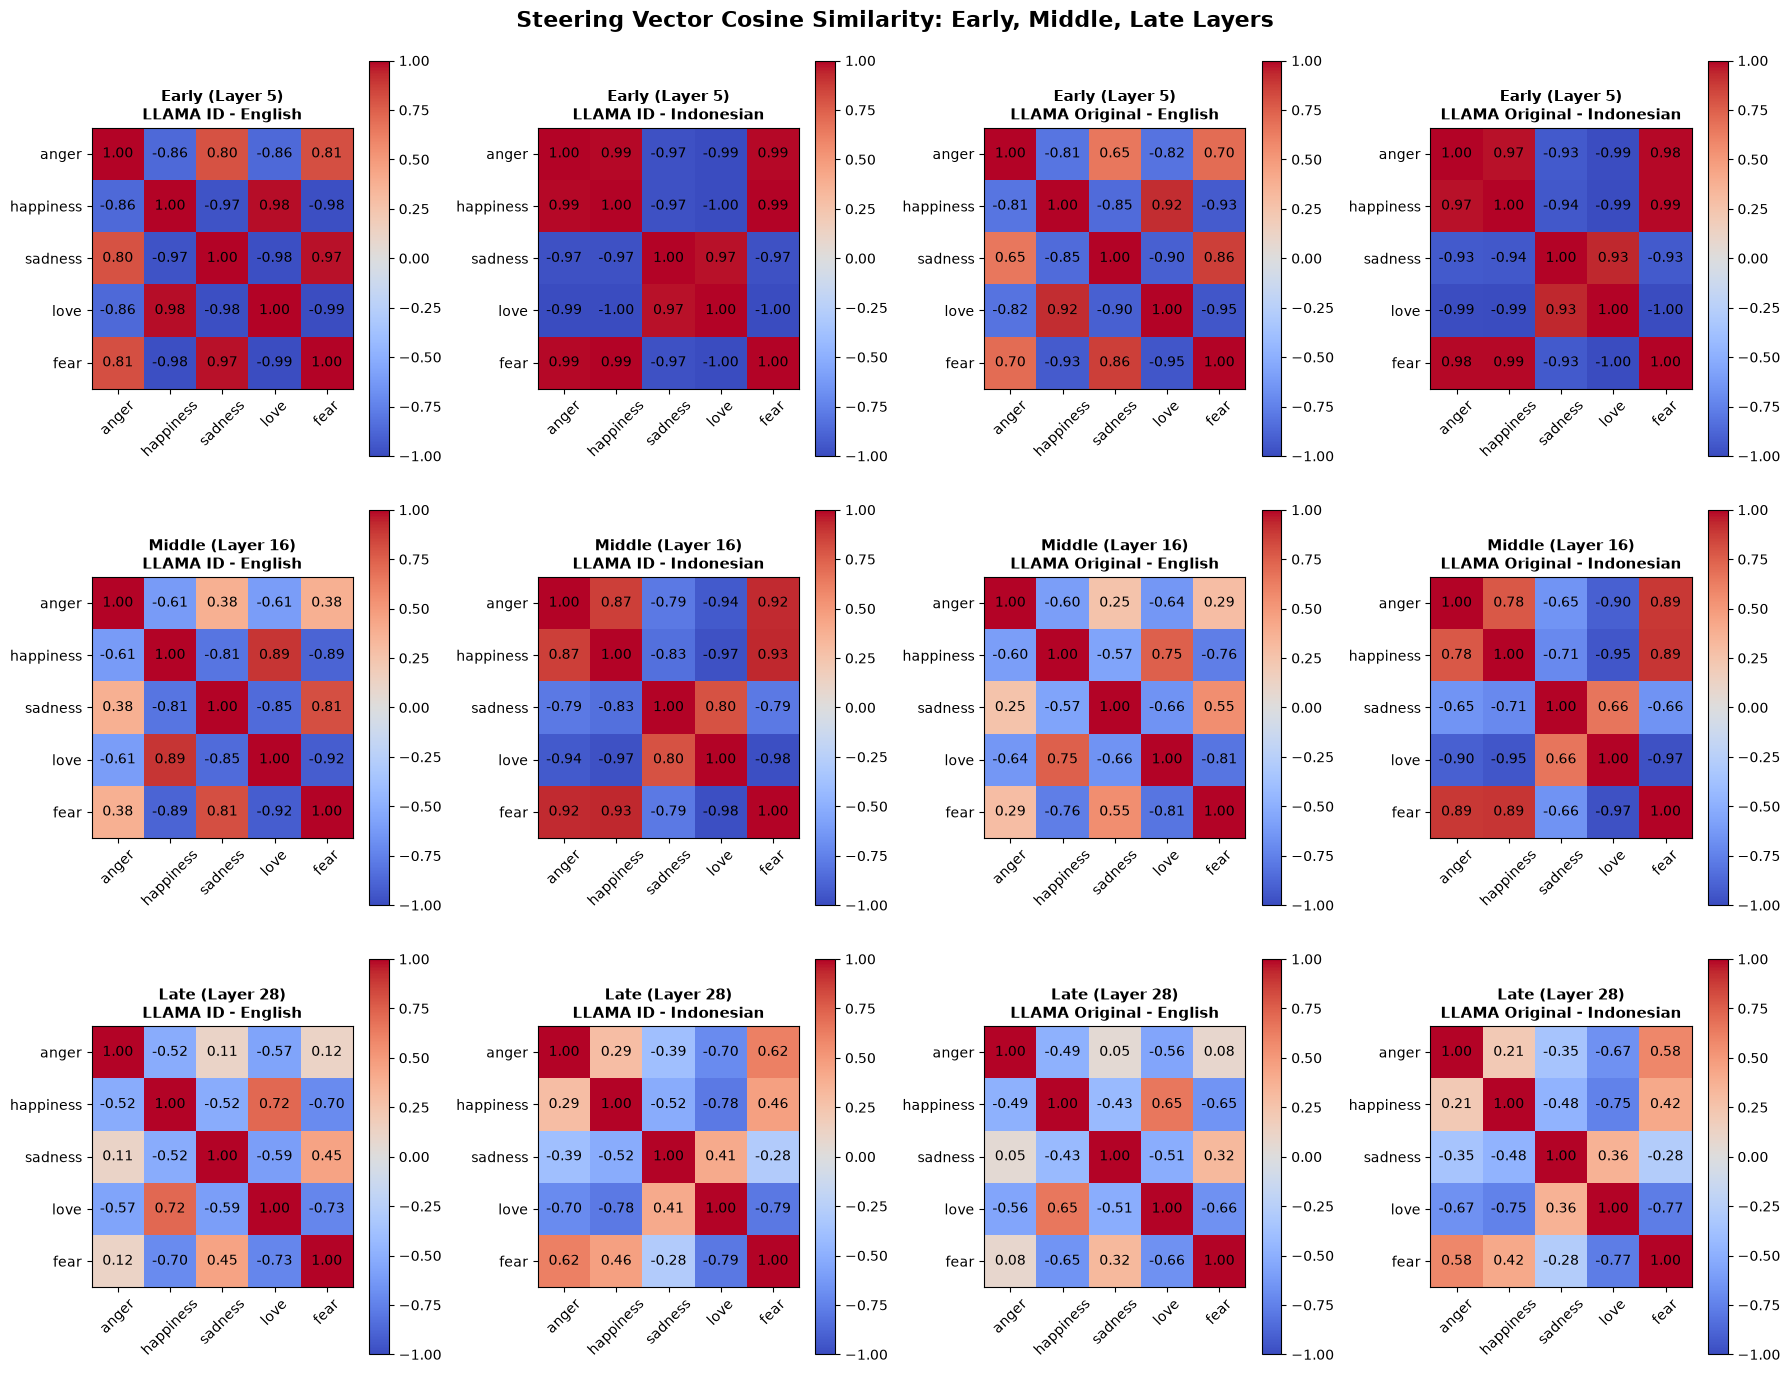

In [25]:

# Cosine matrices across early, middle, and late layers
layer_selection = [5, 16, 28]
layer_labels = ['Early (Layer 5)', 'Middle (Layer 16)', 'Late (Layer 28)']

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for row, (layer_idx, layer_label) in enumerate(zip(layer_selection, layer_labels)):
    # Build cosine matrices for this layer
    llamaid_eng_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_eng, emotions, layer_idx)
    llamaid_id_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_id, emotions, layer_idx)
    llamaeng_eng_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_eng, emotions, layer_idx)
    llamaeng_id_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_id, emotions, layer_idx)
    
    # Column 0: LLAMA ID - English
    im0 = axes[row, 0].imshow(llamaid_eng_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 0].set_xticks(range(len(emotions)))
    axes[row, 0].set_yticks(range(len(emotions)))
    axes[row, 0].set_xticklabels(emotions, rotation=45)
    axes[row, 0].set_yticklabels(emotions)
    axes[row, 0].set_title(f'{layer_label}\nLLAMA ID - English', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 0], llamaid_eng_matrix.values)
    plt.colorbar(im0, ax=axes[row, 0])
    
    # Column 1: LLAMA ID - Indonesian
    im1 = axes[row, 1].imshow(llamaid_id_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 1].set_xticks(range(len(emotions)))
    axes[row, 1].set_yticks(range(len(emotions)))
    axes[row, 1].set_xticklabels(emotions, rotation=45)
    axes[row, 1].set_yticklabels(emotions)
    axes[row, 1].set_title(f'{layer_label}\nLLAMA ID - Indonesian', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 1], llamaid_id_matrix.values)
    plt.colorbar(im1, ax=axes[row, 1])
    
    # Column 2: LLAMA Original - English
    im2 = axes[row, 2].imshow(llamaeng_eng_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 2].set_xticks(range(len(emotions)))
    axes[row, 2].set_yticks(range(len(emotions)))
    axes[row, 2].set_xticklabels(emotions, rotation=45)
    axes[row, 2].set_yticklabels(emotions)
    axes[row, 2].set_title(f'{layer_label}\nLLAMA Original - English', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 2], llamaeng_eng_matrix.values)
    plt.colorbar(im2, ax=axes[row, 2])
    
    # Column 3: LLAMA Original - Indonesian
    im3 = axes[row, 3].imshow(llamaeng_id_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 3].set_xticks(range(len(emotions)))
    axes[row, 3].set_yticks(range(len(emotions)))
    axes[row, 3].set_xticklabels(emotions, rotation=45)
    axes[row, 3].set_yticklabels(emotions)
    axes[row, 3].set_title(f'{layer_label}\nLLAMA Original - Indonesian', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 3], llamaeng_id_matrix.values)
    plt.colorbar(im3, ax=axes[row, 3])

plt.suptitle('Steering Vector Cosine Similarity: Early, Middle, Late Layers', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Bootstrap Analysis

In [11]:
# Bootstrap steering-vector cosine matrices for all model-language conditions
bootstrap_conditions = {
    "Llama_ID_English": mdfLLAMAD_ID_eng,
    "Llama_ID_Indonesian": mdfLLAMAD_ID_id,
    "Llama_ENG_English": mdfLLAMAD_ENG_eng,
    "Llama_ENG_Indonesian": mdfLLAMAD_ENG_id,
}

results_by_condition = {}

for condition, emotion_vectors in bootstrap_conditions.items():
    print(f"Bootstrapping {condition}...")
    results_by_condition[condition] = analysis.bootstrap_steering_cosine_matrices(
        emotion_vectors,
        num_bootstrap=1000,
        confidence_level=0.95,
        paired=True,
        seed=42,
    )

print("Completed bootstrap analysis for all four conditions.")

,anger,happiness,sadness,love,fear
anger,1.000,-0.177,-0.351,-0.041,-0.266
happiness,-0.177,1.000,-0.588,0.572,-0.661
sadness,-0.351,-0.588,1.000,-0.753,0.674
love,-0.041,0.572,-0.753,1.000,-0.788
fear,-0.266,-0.661,0.674,-0.788,1.000


,anger,happiness,sadness,love,fear
anger,0.000,0.327,0.320,0.339,0.316
happiness,0.327,0.000,0.272,0.253,0.240
sadness,0.320,0.272,0.000,0.155,0.201
love,0.339,0.253,0.155,0.000,0.136
fear,0.316,0.240,0.201,0.136,0.000


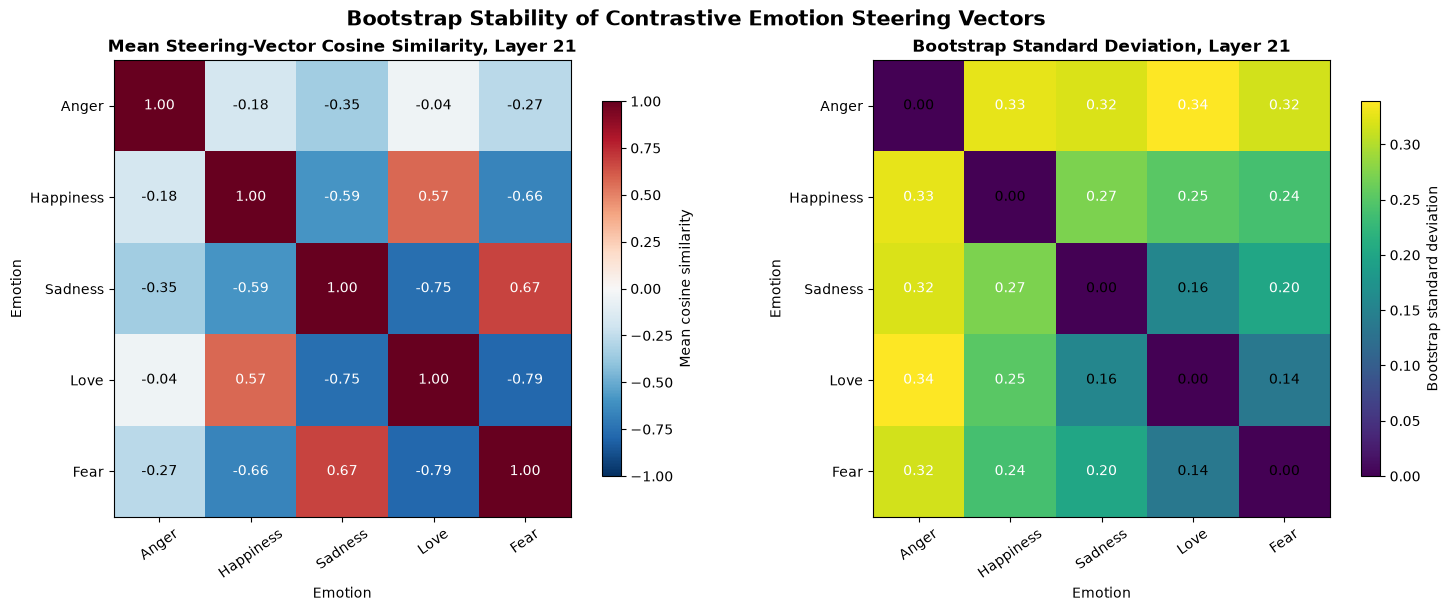

Saved figure to images/cosine_similarity_results/bootstrap_cosine_matrix_layer_21.png


In [12]:
# Plot all four existing bootstrap results without rerunning the bootstrap
import matplotlib.pyplot as plt
from pathlib import Path

plot_layer = 21
condition_labels = {
    "Llama_ID_English": "Llama Indonesian, English vectors",
    "Llama_ID_Indonesian": "Llama Indonesian, Indonesian vectors",
    "Llama_ENG_English": "Llama English, English vectors",
    "Llama_ENG_Indonesian": "Llama English, Indonesian vectors",
}

max_std = max(
    float(np.nanmax(condition_results["bootstrap_std"][plot_layer]))
    for condition_results in results_by_condition.values()
)

fig, axes = plt.subplots(
    len(condition_labels),
    2,
    figsize=(15, 22),
    constrained_layout=True,
)

mean_image = None
std_image = None

for row, (condition, condition_label) in enumerate(condition_labels.items()):
    condition_results = results_by_condition[condition]
    emotions = condition_results["emotions"]
    emotion_labels = [emotion.title() for emotion in emotions]
    mean_values = condition_results["bootstrap_mean"][plot_layer]
    std_values = condition_results["bootstrap_std"][plot_layer]

    mean_ax = axes[row, 0]
    std_ax = axes[row, 1]

    mean_image = mean_ax.imshow(
        mean_values,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        aspect="equal",
    )
    std_image = std_ax.imshow(
        std_values,
        cmap="viridis",
        vmin=0,
        vmax=max(0.01, max_std),
        aspect="equal",
    )

    for ax in (mean_ax, std_ax):
        ax.set_xticks(range(len(emotions)), labels=emotion_labels)
        ax.set_yticks(range(len(emotions)), labels=emotion_labels)
        ax.tick_params(axis="x", rotation=35)
        ax.set_xlabel("Emotion")
        ax.set_ylabel("Emotion")

    for emotion_row in range(len(emotions)):
        for emotion_column in range(len(emotions)):
            mean_value = mean_values[emotion_row, emotion_column]
            std_value = std_values[emotion_row, emotion_column]

            mean_ax.text(
                emotion_column,
                emotion_row,
                f"{mean_value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(mean_value) > 0.45 else "black",
                fontsize=9,
            )
            std_ax.text(
                emotion_column,
                emotion_row,
                f"{std_value:.2f}",
                ha="center",
                va="center",
                color="white" if std_value > max_std * 0.55 else "black",
                fontsize=9,
            )

    mean_ax.set_title(
        f"{condition_label}\nMean cosine similarity",
        fontweight="bold",
    )
    std_ax.set_title(
        f"{condition_label}\nBootstrap standard deviation",
        fontweight="bold",
    )

fig.colorbar(
    mean_image,
    ax=axes[:, 0],
    shrink=0.55,
    pad=0.03,
    label="Mean cosine similarity",
)
fig.colorbar(
    std_image,
    ax=axes[:, 1],
    shrink=0.55,
    pad=0.03,
    label="Bootstrap standard deviation",
)
fig.suptitle(
    f"Bootstrap Stability of Emotion Steering Vectors at Layer {plot_layer}",
    fontsize=17,
    fontweight="bold",
)

output_directory = Path("images/cosine_similarity_results")
output_directory.mkdir(parents=True, exist_ok=True)
output_path = output_directory / f"all_conditions_bootstrap_cosine_layer_{plot_layer}.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure to {output_path}")